## 08_Try_Image_enconder and decocer

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'api_stable').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from api_stable.mammography import MammographyDicom

In [2]:
PNG_PATH = Path('/home/eloygarcia/Escritorio/Datasets/RSNA_png/train_images/5/640805896.png')
if not PNG_PATH.exists():
    raise FileNotFoundError(f'Actualiza PNG_PATH: {PNG_PATH}')

print('PNG_PATH =', PNG_PATH)

PNG_PATH = /home/eloygarcia/Escritorio/Datasets/RSNA_png/train_images/5/640805896.png


39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
39.0 240.0
159.03 53.98
MammographyMetadata(patient=PatientInfo(patient_id=None, age=None, sex=None), vendor=VendorInfo(manufacturer='HOLOGIC, Inc.', model_name='Selenia Dimensions'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality=None, view=None, breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=8, pixel_spacing=(0.07, 0.07), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=159, window_width=53, window_center_width_explanation='AUTO', voi_lut_function='LINEAR'))


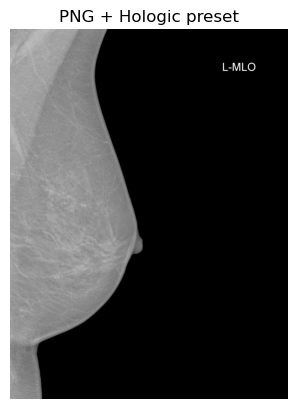

In [3]:
mammo_hologic = MammographyDicom.from_png(
    PNG_PATH,
    metadata_preset='Hologic',
)

print(mammo_hologic.metadata)

original = mammo_hologic.image.to_numpy()

plt.imshow(original, cmap='gray')
plt.title('PNG + Hologic preset')
plt.axis('off')
plt.show()

In [4]:
from plugin_framework.encoder_service import ImageEncoder

In [5]:
encoder = ImageEncoder()

In [6]:
encoder.encode(mammo_hologic)

tmp/1.2.826.0.1.3680043.8.498.89315504991079208870315634935952639899.nii.gz


{'image': PosixPath('tmp/1.2.826.0.1.3680043.8.498.89315504991079208870315634935952639899.nii.gz'),
 'metadata': {'patient': {'patient_id': None, 'age': None, 'sex': None},
  'vendor': {'manufacturer': 'HOLOGIC, Inc.',
   'model_name': 'Selenia Dimensions'},
  'acquisition': {'kvp': None,
   'exposure': None,
   'exposure_time': None,
   'tube_current': None,
   'compression_force': None},
  'breast': {'laterality': None, 'view': None, 'breast_implant_present': None},
  'image': {'rows': 2776,
   'columns': 2082,
   'bits_stored': 8,
   'pixel_spacing': (0.07, 0.07),
   'photometric_interpretation': 'MONOCHROME2',
   'presentation_lut_shape': 'IDENTITY',
   'window_center': 159,
   'window_width': 53,
   'window_center_width_explanation': 'AUTO',
   'voi_lut_function': 'LINEAR'}}}

In [7]:
import numpy as np
isinstance(mammo_hologic.image.to_numpy(),np.ndarray)

True

In [8]:
print(mammo_hologic.metadata)

MammographyMetadata(patient=PatientInfo(patient_id=None, age=None, sex=None), vendor=VendorInfo(manufacturer='HOLOGIC, Inc.', model_name='Selenia Dimensions'), acquisition=AcquisitionInfo(kvp=None, exposure=None, exposure_time=None, tube_current=None, compression_force=None), breast=BreastInfo(laterality=None, view=None, breast_implant_present=None), image=ImageInfo(rows=2776, columns=2082, bits_stored=8, pixel_spacing=(0.07, 0.07), photometric_interpretation='MONOCHROME2', presentation_lut_shape='IDENTITY', window_center=159, window_width=53, window_center_width_explanation='AUTO', voi_lut_function='LINEAR'))


In [9]:
from dataclasses import asdict

asdict(mammo_hologic.metadata)['breast']['view'] == None

True

In [10]:
mammo_hologic.get_internal_uid()

'1.2.826.0.1.3680043.8.498.89315504991079208870315634935952639899'